# GWASLab Cohort Processing Pipeline

Standalone GWASLab processing pipeline for GWAS summary statistics.

Accepts a summary-statistics file, population, reference, and optional dbSNP mapping, plotting and QC parameters, then runs:

- basic_check
- remove_dup
- [liftover] -- optional, either from build 37 to 38 or from build 38 to 37, depending on the input build and reference build
- check_ref
- flip_allele_stats
- fix_id
- infer_strand
- flip_allele_stats
- [assign_rsid (dbSNP)] -- optional
- check_af
- save raw output
- [QC filter] -- optional
  - save QC output
- [lead SNPs] -- optional
  - save lead SNPs output

Expected input columns:

- VariantID as `CHR:BP:REF:ALT` or rsID
- CHR
- BP
- EffectAllele and OtherAllele or Allele1 and Allele2 or A1 and A2 or MinorAllele and MajorAllele
- EAF or AF or MAF
- MAC -- optional, but required for QC, if not provided, will be inferred from EAF and N
- HWE_P -- optional, but required for QC, if not provided QC will be done without HWE filter
- Beta or OR or BetaMinor
- SE
- P
- N or N_cases and N_controls (N will be inferred from N_cases and N_controls if not provided)
- Info -- optional, but required for QC, if not provided QC will be done without INFO filter
- Imputed -- optional, will be set to NO if not provided, or if INFO is provided and Imputed is not provided will be set to YES
- Strand -- optional

Usage example:

```
  python3 gwaslab.process.py \\
      --gwas       MyStudy \\
      --input      MyStudy.parsed.txt.gz \\
      --directory  /data/results/MyStudy \\
      --ref        /data/references/ \\
      --output     /data/results/MyStudy/GWASCatalog \\
      --population EUR \\
      --build      19 \\
      --dbSNP      YES \\
      --qc         YES
```


In [2]:
# General packages
import os
import gzip
import shutil

# Visualization packages
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation packages
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

# GWASLab package
import gwaslab as gl


## 1 · Parameters

Edit these before running the notebook.


In [3]:
# ── Study / paths ────────────────────────────────────────────────────────────
PHENOTYPE  = "AFGen"                        # study name; used in output filenames
INPUT      = "AF_TOPMed_Meta_2021_Freeze5_ALL_v21_chr1_22_common.txt.gz"          # filename (relative to GWAS_DIR) or absolute path
GWAS_DIR   = "/Users/slaan3/Downloads/Roselli2018"          # directory containing the input file
REF_loc    = f"/Users/slaan3/Library/CloudStorage/OneDrive-UMCUtrecht/Genomics/PLINK/references/gwaslab"              # references dir (FASTA, 1KG VCFs, dbSNP VCFs)
OUTPUT_loc = f"/Users/slaan3/git/gwas2cojo/data/{PHENOTYPE}/GWASCatalog"   # where to write output
print(f"[INFO] Study parameters set for [ {PHENOTYPE} ].")
print(f"   Input file............: {os.path.join(GWAS_DIR, INPUT)}")
print(f"   Reference directory...: {REF_loc}")
print(f"   Output directory......: {OUTPUT_loc}")

# ── Population / build ───────────────────────────────────────────────────────
POPULATION = "EUR"    # ancestry code (EUR, AFR, EAS, AMR, SAS, PAN)
REFERENCE  = "19"     # genome build: "19" or "38"
# Map REFERENCE to the correct 1KG filename suffix
REF_FILENAME_MAP = {
    "hg19":   f"{POPULATION}.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz",
    "GRCh37": f"{POPULATION}.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz",
    "19":     f"{POPULATION}.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz",
    "hg38":   f"{POPULATION}.ALL.split_norm_af.1kg_30x.hg38.vcf.gz",
    "GRCh38": f"{POPULATION}.ALL.split_norm_af.1kg_30x.hg38.vcf.gz",
    "38":     f"{POPULATION}.ALL.split_norm_af.1kg_30x.hg38.vcf.gz",
}

ref_filename = REF_FILENAME_MAP.get(REFERENCE)
if ref_filename is None:
    raise ValueError(f"[ERROR] Unknown REFERENCE '{REFERENCE}' — expected one of: {list(REF_FILENAME_MAP.keys())}")

ref_path = os.path.join(REF_loc, ref_filename)

if not os.path.isfile(ref_path):
    raise FileNotFoundError(f"[ERROR] Reference VCF not found: {ref_path}")

print(f"[INFO] Reference population set to [ {POPULATION} ] and genome build set to [ GRCh{REFERENCE} ].")
print(f"[INFO] Using reference VCF: {ref_path}")

# ── Pipeline toggles ─────────────────────────────────────────────────────────
DO_LIFTOVER  = True   # liftover from hg19 > hg38
DO_DBSNP     = True    # assign rsIDs from dbSNP
DO_QC        = True    # apply QC filters
ONLY_QC      = False   # skip loading; reload from existing .pkl and run QC only
MAKE_FIGURES = True    # generate plots
SELECT_LEADS = True    # extract genome-wide significant lead SNPs (p < 5e-8)
N_CORES      = 8
print("[INFO] Pipeline toggles set.")
print(f"   LiftOver: {DO_LIFTOVER} | dbSNP annotation: {DO_DBSNP} | QC: {DO_QC} | Only QC: {ONLY_QC} | Make figures: {MAKE_FIGURES} | Select leads: {SELECT_LEADS} | N cores: {N_CORES}")

# ── QC thresholds ────────────────────────────────────────────────────────────
EAF_THRESHOLD = 0.005   # EAF lower bound (also removes EAF > 1 - threshold)
BETA_MAX      = 5.0     # maximum |BETA|
SE_MAX        = 5.0     # maximum SE
INFO_MIN      = 0.4     # minimum INFO score
HWE_MIN       = 1e-3    # minimum HWE p-value
MAC_MIN       = 30      # minimum minor allele count
DAF_MAX       = 0.12    # maximum |DAF|; set to None to skip the DAF filter
print("[INFO] QC thresholds set.")
print(f"   EAF threshold: {EAF_THRESHOLD} | BETA max: {BETA_MAX} | SE max: {SE_MAX} | INFO min: {INFO_MIN} | HWE min: {HWE_MIN} | MAC min: {MAC_MIN} | DAF max: {DAF_MAX}")

print("[INFO] Parameters set.")

[INFO] Study parameters set for [ AFGen ].
   Input file............: /Users/slaan3/Downloads/Roselli2018/AF_TOPMed_Meta_2021_Freeze5_ALL_v21_chr1_22_common.txt.gz
   Reference directory...: /Users/slaan3/Library/CloudStorage/OneDrive-UMCUtrecht/Genomics/PLINK/references/gwaslab
   Output directory......: /Users/slaan3/git/gwas2cojo/data/AFGen/GWASCatalog
[INFO] Reference population set to [ EUR ] and genome build set to [ GRCh19 ].
[INFO] Using reference VCF: /Users/slaan3/Library/CloudStorage/OneDrive-UMCUtrecht/Genomics/PLINK/references/gwaslab/EUR.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz
[INFO] Pipeline toggles set.
   LiftOver: True | dbSNP annotation: True | QC: True | Only QC: False | Make figures: True | Select leads: True | N cores: 8
[INFO] QC thresholds set.
   EAF threshold: 0.005 | BETA max: 5.0 | SE max: 5.0 | INFO min: 0.4 | HWE min: 0.001 | MAC min: 30 | DAF max: 0.12
[INFO] Parameters set.


## 2 · Reference files

Download necessary reference files (FASTA, 1KG VCFs, dbSNP VCFs) to the `REF_loc` directory before running the pipeline.


In [4]:
# Set a default download folder
# gl.check_available_ref()
# {'1kg_eas_hg19': {'description': '1000 Genomes Project East Asian (1KG EAS) VCF on the hg19 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the EAS population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for EAS population'},
#  '1kg_eur_hg19': {'description': '1000 Genomes Project European (1KG EUR) VCF on the hg19 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the EUR population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for EUR population'},
#  '1kg_eas_hg38': {'description': '1000 Genomes Project East Asian (1KG EAS) VCF on the hg38 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the EAS population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for EAS population'},
#  '1kg_eur_hg38': {'description': '1000 Genomes Project European (1KG EUR) VCF on the hg38 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the EUR population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for EUR population'},
#  '1kg_sas_hg19': {'description': '1000 Genomes Project South Asian (1KG SAS) VCF on the hg19 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the SAS population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for SAS population'},
#  '1kg_amr_hg19': {'description': '1000 Genomes Project American (1KG AMR) VCF on the hg19 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the AMR population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for AMR population'},
#  '1kg_sas_hg38': {'description': '1000 Genomes Project South Asian (1KG SAS) VCF on the hg38 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the SAS population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for SAS population'},
#  '1kg_amr_hg38': {'description': '1000 Genomes Project American (1KG AMR) VCF on the hg38 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the AMR population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for AMR population'},
#  '1kg_afr_hg19': {'description': '1000 Genomes Project African (1KG AFR) VCF on the hg19 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the AFR population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for AFR population'},
#  '1kg_pan_hg19': {'description': '1000 Genomes Project Pan-ancestry (1KG PAN) VCF on the hg19 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the PAN population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for PAN population'},
#  '1kg_afr_hg38': {'description': '1000 Genomes Project African (1KG AFR) VCF on the hg38 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the AFR population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for AFR population'},
#  '1kg_pan_hg38': {'description': '1000 Genomes Project Pan-ancestry (1KG PAN) VCF on the hg38 reference. Multi-allelic variants were decomposed. Variants were normalized. The INFO field includes the AF annotation, representing allele frequency in the PAN population.',
#   'suggested_use': 'LD reference panel for creating region plot; infer strand for PAN population'},
#  'dbsnp_v151_hg19': {'description': 'dbSNP v151 hg19 is the 2018 release of the dbSNP database mapped to the human genome assembly GRCh37/hg19, providing standardized rsID identifiers and allele information for known genetic variants.',
#   'suggested_use': 'rsID assignment'},
#  'dbsnp_v151_hg38': {'description': 'dbSNP v151 hg38 is the 2018 release of the dbSNP database mapped to the human genome assembly GRCh38, providing standardized rsID identifiers and allele information for known genetic variants.',
#   'suggested_use': 'rsID assignment'},
#  'dbsnp_v157_hg19': {'description': 'dbSNP v157 hg19 is the release of the dbSNP database mapped to the human genome assembly GRCh37/hg19, providing standardized rsID identifiers and allele information for known genetic variants.',
#   'suggested_use': 'rsID assignment'},
#  'dbsnp_v157_hg38': {'description': 'dbSNP v157 hg38 is the release of the dbSNP database mapped to the human genome assembly GRCh38, providing standardized rsID identifiers and allele information for known genetic variants.',
#   'suggested_use': 'rsID assignment'},
#  'ucsc_genome_hg19': {'description': 'UCSC Genome reference sequence on hg19 (GRCh37), providing the complete human genome assembly used for alignment and variant annotation.',
#   'suggested_use': 'Reference genome for alignment and annotation'},
#  'ucsc_genome_hg38': {'description': 'UCSC Genome reference sequence on hg38 (GRCh38), providing the complete human genome assembly used for alignment and variant annotation.',
#   'suggested_use': 'Reference genome for alignment and annotation'},
#  '1kg_dbsnp151_hg19_auto': {'description': '1KG dbSNP151 hg19 auto variants table containing SNP ID, chromosome, position, effect allele, non-effect allele, and rsID mappings for autosomal variants.',
#   'suggested_use': 'SNP annotation and rsID mapping'},
#  '1kg_dbsnp151_hg38_auto': {'description': '1KG dbSNP151 hg38 auto variants table containing SNP ID, chromosome, position, effect allele, non-effect allele, and rsID mappings for autosomal variants.',
#   'suggested_use': 'SNP annotation and rsID mapping'},
#  'recombination_hg19': {'description': 'Recombination map for hg19 (GRCh37), providing genetic distance estimates in centimorgans used for linkage disequilibrium and haplotype analysis.',
#   'suggested_use': 'Genetic mapping and LD calculations'},
#  'recombination_hg38': {'description': 'Recombination map for hg38 (GRCh38), providing genetic distance estimates in centimorgans used for linkage disequilibrium and haplotype analysis.',
#   'suggested_use': 'Genetic mapping and LD calculations'},
#  'ensembl_hg19_gtf': {'description': 'Ensembl annotation for hg19 (GRCh37) release 87, providing comprehensive gene models, transcript structures, and functional annotations for the human genome.',
#   'suggested_use': 'Gene annotation and functional analysis'},
#  'ensembl_hg38_gtf': {'description': 'Ensembl annotation for hg38 (GRCh38) release 109, providing comprehensive gene models, transcript structures, and functional annotations for the human genome.',
#   'suggested_use': 'Gene annotation and functional analysis'},
#  'refseq_hg19_gtf': {'description': 'RefSeq annotation for hg19 (GRCh37), providing curated gene models and transcript structures for the human genome.',
#   'suggested_use': 'Gene annotation and functional analysis'},
#  'refseq_hg38_gtf': {'description': 'RefSeq annotation for hg38 (GRCh38), providing curated gene models and transcript structures for the human genome.',
#   'suggested_use': 'Gene annotation and functional analysis'},
#  'testlink': {'description': 'Test link', 'suggested_use': ''},
#  '19to38': {'description': 'LiftOver chain file for converting genomic coordinates from hg19 (GRCh37) to hg38 (GRCh38) reference builds, enabling cross-reference genome analysis.',
#   'suggested_use': 'Genome build conversion and coordinate remapping'},
#  '38to19': {'description': 'LiftOver chain file for converting genomic coordinates from hg38 (GRCh38) to hg19 (GRCh37) reference builds, enabling cross-reference genome analysis.',
#   'suggested_use': 'Genome build conversion and coordinate remapping'},
#  '1kg_hm3_hg38_eaf': {'description': '1KG HapMap3 hg38 EAF (GRCh38) provides allele frequency estimates for the HapMap3 populations on the hg38 reference genome, derived from 1000 Genomes Project data.',
#   'suggested_use': 'Ancestry inference and population structure analysis'},
#  '1kg_hm3_hg19_eaf': {'description': '1KG HapMap3 hg19 EAF (GRCh37) provides allele frequency estimates for the HapMap3 populations on the hg19 reference genome, derived from 1000 Genomes Project data.',
#   'suggested_use': 'Ancestry inference and population structure analysis'}}

# gl.set_default_directory("/Users/slaan3/Library/CloudStorage/OneDrive-UMCUtrecht/Genomics/PLINK/references/gwaslab")

gl.options.set_option("data_directory", "/Users/slaan3/Library/CloudStorage/OneDrive-UMCUtrecht/Genomics/PLINK/references/gwaslab")
# Verify it was set
print(gl.options.get_option())

{'config': '/Users/slaan3/miniforge3/envs/gwas2cojo/lib/python3.12/site-packages/gwaslab/data/config.json', 'reference': '/Users/slaan3/miniforge3/envs/gwas2cojo/lib/python3.12/site-packages/gwaslab/data/reference.json', 'formatbook': '/Users/slaan3/miniforge3/envs/gwas2cojo/lib/python3.12/site-packages/gwaslab/data/formatbook.json', 'data_directory': '/Users/slaan3/Library/CloudStorage/OneDrive-UMCUtrecht/Genomics/PLINK/references/gwaslab'}


In [5]:

# hg19/build 37 reference files
# 1KG VCFs
gl.download_ref("1kg_eur_hg19")
gl.download_ref("1kg_pan_hg19")
# gl.download_ref("1kg_eas_hg19")
# gl.download_ref("1kg_sas_hg19")
# gl.download_ref("1kg_amr_hg19")
# gl.download_ref("1kg_afr_hg19")
gl.download_ref("1kg_hm3_hg19_eaf")
# dbSNP VCFs
gl.download_ref("dbsnp_v151_hg19")
gl.download_ref("dbsnp_v157_hg19")

# hg38/build 38 reference files
# 1KG VCFs
gl.download_ref("1kg_eur_hg38")
gl.download_ref("1kg_pan_hg38")
# gl.download_ref("1kg_eas_hg38")
# gl.download_ref("1kg_sas_hg38")
# gl.download_ref("1kg_amr_hg38")
# gl.download_ref("1kg_afr_hg38")
gl.download_ref("1kg_hm3_hg38_eaf")
# dbSNP VCFs
gl.download_ref("dbsnp_v151_hg38")
gl.download_ref("dbsnp_v157_hg38")

# gene annotation files
gl.download_ref("recombination_hg19")
gl.download_ref("recombination_hg38")
gl.download_ref("ensembl_hg19_gtf")
gl.download_ref("ensembl_hg38_gtf")
gl.download_ref("refseq_hg19_gtf")
gl.download_ref("refseq_hg38_gtf")

2026/03/11 22:59:59 Start to download  1kg_eur_hg19  ...
2026/03/11 22:59:59  -Downloading to: /Users/slaan3/Library/CloudStorage/OneDrive-UMCUtrecht/Genomics/PLINK/references/gwaslab/EUR.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz
2026/03/11 22:59:59  -File /Users/slaan3/Library/CloudStorage/OneDrive-UMCUtrecht/Genomics/PLINK/references/gwaslab/EUR.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz exists.
2026/03/11 22:59:59  - Updating record in config file...
2026/03/11 22:59:59  -Downloading to: /Users/slaan3/Library/CloudStorage/OneDrive-UMCUtrecht/Genomics/PLINK/references/gwaslab/EUR.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz.tbi
2026/03/11 22:59:59  -File /Users/slaan3/Library/CloudStorage/OneDrive-UMCUtrecht/Genomics/PLINK/references/gwaslab/EUR.ALL.split_norm_af.1kgp3v5.hg19.vcf.gz.tbi exists.
2026/03/11 22:59:59  - Updating record in config file...
2026/03/11 22:59:59 Downloaded  1kg_eur_hg19  successfully!
2026/03/11 22:59:59 Start to download  1kg_pan_hg19  ...
2026/03/11 22:59:59  -Downloading 

## 3 · Helper functions


In [6]:
# Make directory if it doesn't exist
def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

# Write DataFrame as tab-separated .gz; removes the uncompressed copy.
def save_tsv_gz(df, path):
    """Write DataFrame as tab-separated .gz; removes the uncompressed copy."""
    df.to_csv(path, sep="\t", index=False)
    with open(path, "rb") as f_in, gzip.open(path + ".gz", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    os.remove(path)

# Defined once here so all subsequent blocks can use it
def resolve_column(df, aliases):
    """Return the first matching column name from df, case-insensitively."""
    df_cols_lower = {c.lower(): c for c in df.columns}
    for alias in aliases:
        if alias.lower() in df_cols_lower:
            return df_cols_lower[alias.lower()]
    return None

# Reformat column names for output
def reformat_output(df):
    """Rename GWASLab internal column names back to MetaGWASToolKit convention."""
    df = df.rename(columns={
        "POS":  "BP",
        "EA":   "EffectAllele",
        "NEA":  "OtherAllele",
        "INFO": "Info",
        "BETA": "Beta",
    })
    if "VariantID" not in df.columns:
        df["VariantID"] = df.get("SNPID", df.get("MarkerOriginal", ""))
    if "BetaMinor" not in df.columns and "Beta" in df.columns:
        df["BetaMinor"] = df["Beta"]
    if "MAF" not in df.columns and "EAF" in df.columns:
        df["MAF"] = df["EAF"]
    desired = [
        "VariantID", "MarkerOriginal", "rsID", "CHR", "BP", "Strand",
        "EffectAllele", "OtherAllele", "MinorAllele", "MajorAllele",
        "EAF", "MAF", "MAC", "HWE_P", "Info",
        "Beta", "BetaMinor", "SE", "P",
        "N", "N_cases", "N_controls", "Imputed", "DAF",
    ]
    df = df[[c for c in desired if c in df.columns]]
    for col in df.select_dtypes(include="category").columns:
        df[col] = df[col].cat.add_categories(["NA"])
    return df.fillna("NA")

# Coerce specified columns to numeric, setting non-convertible values to NaN
def coerce_numeric_cols(data, cols):
    for col in cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

# Plot histogram of a specified column
def plot_histogram(data, col, label, color, save_path):
    plt.figure()
    sns.histplot(data=data, x=col, bins=25, kde=False, stat="frequency", color=color)
    plt.title(f"Histogram of {label}")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

# Construct file paths for reference VCFs based on population and build
def ref_vcf_path(ref_dir, population, build):
    fname = (
        f"{population}.ALL.split_norm_af.1kgp3v5.hg{build}.vcf.gz"
        if build == "19"
        else f"{population}.ALL.split_norm_af.1kg_30x.hg{build}.vcf.gz"
    )
    return os.path.join(ref_dir, fname)

# Construct file paths for dbSNP VCFs based on build
def dbsnp_vcf_path(ref_dir, build):
    fname = "GCF_000001405.25.gz" if build == "19" else "GCF_000001405.40.gz"
    return os.path.join(ref_dir, fname)

# Construct QC filter expression based on specified thresholds
def build_qc_filter_expr(eaf, beta, se, info, daf):
    filters = [f"(EAF >= {eaf} & EAF < {1 - eaf})"]
    if beta is not None:
        filters.append(f"(BETA >= {-beta} & BETA <= {beta})")
    if se is not None:
        filters.append(f"(SE <= {se})")
    if info is not None:
        filters.append(f"(INFO >= {info})")
    if daf is not None:
        filters.append(f"(DAF < {daf} & DAF > {-daf})")
    return " & ".join(filters)

print("Helper functions defined.")

Helper functions defined.


In [7]:
################################################################################
#                                PROJECT COLORS                                #
################################################################################

### Utrecht Science Park Colour Scheme
###
### Website to convert HEX to RGB: http://hex.colorrrs.com.
### For some functions you should divide these numbers by 255.
###
###  No.  Color                HEX       (RGB)                        CHR      MAF/INFO
### -------------------------------------------------------------------------------------
###   1   yellow               #FBB820   (251,184,32)             =>   1    or 1.0>INFO
###   2   gold                 #F59D10   (245,157,16)             =>   2
###   3   salmon               #E55738   (229,87,56)              =>   3    or 0.05<MAF<0.2 or 0.4<INFO<0.6
###   4   darkpink             #DB003F   (219,0,63)               =>   4
###   5   lightpink            #E35493   (227,84,147)             =>   5    or 0.8<INFO<1.0
###   6   pink                 #D5267B   (213,38,123)             =>   6
###   7   hardpink             #CC0071   (204,0,113)              =>   7
###   8   lightpurple          #A8448A   (168,68,138)             =>   8
###   9   purple               #9A3480   (154,52,128)             =>   9
###  10   lavendel             #8D5B9A   (141,91,154)             =>  10
###  11   bluepurple           #705296   (112,82,150)             =>  11
###  12   purpleblue           #686AA9   (104,106,169)            =>  12
###  13   lightpurpleblue      #6173AD   (97,115,173)             =>  13
###  14   seablue              #4C81BF   (76,129,191)             =>  14
###  15   skyblue              #2F8BC9   (47,139,201)             =>  15
###  16   azurblue             #1290D9   (18,144,217)             =>  16   or 0.01<MAF<0.05 or 0.2<INFO<0.4
###  17   lightazurblue        #1396D8   (19,150,216)             =>  17
###  18   greenblue            #15A6C1   (21,166,193)             =>  18
###  19   seaweedgreen         #5EB17F   (94,177,127)             =>  19
###  20   yellowgreen          #86B833   (134,184,51)             =>  20
###  21   lightmossgreen       #C5D220   (197,210,32)             =>  21
###  22   mossgreen            #9FC228   (159,194,40)             =>  22   or MAF>0.20 or 0.6<INFO<0.8
###  23   lightgreen           #78B113   (120,177,19)             =>  23/X
###  24   green                #49A01D   (73,160,29)              =>  24/Y
###  25   grey                 #595A5C   (89,90,92)               =>  25/XY or MAF<0.01 or 0.0<INFO<0.2
###  26   lightgrey            #A2A3A4   (162,163,164)            =>  26/MT
###
###  ADDITIONAL COLORS
###  27   midgrey              #D7D8D7
###  28   verylightgrey        #ECECEC
###  29   white                #FFFFFF
###  30   black                #000000
### -------------------------------------------------------------------------------------

uithof_color = [
    "#FBB820", "#F59D10", "#E55738", "#DB003F", "#E35493", "#D5267B",  #  1- 6
    "#CC0071", "#A8448A", "#9A3480", "#8D5B9A", "#705296", "#686AA9",  #  7-12
    "#6173AD", "#4C81BF", "#2F8BC9", "#1290D9", "#1396D8", "#15A6C1",  # 13-18
    "#5EB17F", "#86B833", "#C5D220", "#9FC228", "#78B113", "#49A01D",  # 19-24
    "#595A5C", "#A2A3A4", "#D7D8D7", "#ECECEC", "#FFFFFF", "#000000",  # 25-30
]

uithof_color_legend = {
    "yellow":           "#FBB820",  #  1
    "gold":             "#F59D10",  #  2
    "salmon":           "#E55738",  #  3
    "darkpink":         "#DB003F",  #  4
    "lightpink":        "#E35493",  #  5
    "pink":             "#D5267B",  #  6
    "hardpink":         "#CC0071",  #  7
    "lightpurple":      "#A8448A",  #  8
    "purple":           "#9A3480",  #  9
    "lavendel":         "#8D5B9A",  # 10
    "bluepurple":       "#705296",  # 11
    "purpleblue":       "#686AA9",  # 12
    "lightpurpleblue":  "#6173AD",  # 13
    "seablue":          "#4C81BF",  # 14
    "skyblue":          "#2F8BC9",  # 15
    "azurblue":         "#1290D9",  # 16
    "lightazurblue":    "#1396D8",  # 17
    "greenblue":        "#15A6C1",  # 18
    "seaweedgreen":     "#5EB17F",  # 19
    "yellowgreen":      "#86B833",  # 20
    "lightmossgreen":   "#C5D220",  # 21
    "mossgreen":        "#9FC228",  # 22
    "lightgreen":       "#78B113",  # 23
    "green":            "#49A01D",  # 24
    "grey":             "#595A5C",  # 25
    "lightgrey":        "#A2A3A4",  # 26
    "midgrey":          "#D7D8D7",  # 27
    "verylightgrey":    "#ECECEC",  # 28
    "white":            "#FFFFFF",  # 29
    "black":            "#000000",  # 30
}

## 4 · Setup directories & GWASLab options


In [8]:
print(f"> Checking downloaded references.")
gl.check_downloaded_ref()

print("Setting GWASLab data directory to reference location.")
gl.options.set_option("data_directory", REF_loc)

# Setting GWASLab data file and directory paths
ensure_dir(OUTPUT_loc)
PLOTS_loc = os.path.join(OUTPUT_loc, "PLOTS")
ensure_dir(PLOTS_loc)

input_path = INPUT if os.path.isabs(INPUT) else os.path.join(GWAS_DIR, INPUT)
pkl_path   = os.path.join(OUTPUT_loc, f"{PHENOTYPE}.hg{REFERENCE}.gwaslab.pkl")
vcf        = ref_vcf_path(REF_loc, POPULATION, REFERENCE)

print("> File paths set:")
print(f"   Input.....: {input_path}")
print(f"   Output....: {OUTPUT_loc}")
print(f"   Pickle....: {pkl_path}")
print(f"   Ref VCF...: {vcf}")

> Checking downloaded references.
2026/03/11 22:59:59 Start to check downloaded reference files...
2026/03/11 22:59:59  -Checking the config file:/Users/slaan3/miniforge3/envs/gwas2cojo/lib/python3.12/site-packages/gwaslab/data/config.json
2026/03/11 22:59:59  -Config file exists.
2026/03/11 22:59:59  -Updating config.json...
2026/03/11 22:59:59  - Local file keywords:  ensembl_hg19_gtf 1kg_hm3_hg19_eaf 1kg_hm3_hg38_eaf refseq_hg38_gtf refseq_hg19_gtf ensembl_hg38_gtf 1kg_eur_hg19 recombination_hg38 recombination_hg19 1kg_pan_hg19 dbsnp_v151_hg19 dbsnp_v157_hg19 1kg_eur_hg38 1kg_pan_hg38 dbsnp_v151_hg38 dbsnp_v157_hg38
Setting GWASLab data directory to reference location.
> File paths set:
   Input.....: /Users/slaan3/Downloads/Roselli2018/AF_TOPMed_Meta_2021_Freeze5_ALL_v21_chr1_22_common.txt.gz
   Output....: /Users/slaan3/git/gwas2cojo/data/AFGen/GWASCatalog
   Pickle....: /Users/slaan3/git/gwas2cojo/data/AFGen/GWASCatalog/AFGen.hg19.gwaslab.pkl
   Ref VCF...: /Users/slaan3/Library/

## 5 · Load data

Set `ONLY_QC = True` (cell 2) to skip loading and reload from an existing pickle instead.


In [9]:
if ONLY_QC:
    print(f"[onlyqc] Loading existing pickle: {pkl_path}")
    gwas_obj = gl.load_pickle(pkl_path)
else:
    print(f"Loading: {input_path}")
    gwas_data = pd.read_csv(
        input_path,
        sep="\t",
        header=0,
        na_values=["NA"],
        dtype={"CHR": "string"},
        engine="pyarrow",
    )
    print(f"Loaded {len(gwas_data):,} variants, {gwas_data.shape[1]} columns")
gwas_data.head()

Loading: /Users/slaan3/Downloads/Roselli2018/AF_TOPMed_Meta_2021_Freeze5_ALL_v21_chr1_22_common.txt.gz
Loaded 18,842,305 variants, 13 columns


,MarkerName,rsid,chr,position_b38,Allele1,Allele2,Freq1,Effect,StdErr,log(P),n_events,n_total,mean_impQual
0,1:105414348:CTG:C,1:105414348,1,105414348,CTG,C,0.5,-0.0027,0.0054,-0.21,123790,1319851.0,0.98
1,1:110197242:A:G,rs2761442,1,110197242,A,G,0.5,-0.0034,0.0043,-0.37,180061,1652899.0,0.97
2,1:110197850:A:G,rs2761444,1,110197850,A,G,0.5,-0.0036,0.0043,-0.39,180061,1652909.0,0.97
3,1:110225230:G:C,rs2784147,1,110225230,C,G,0.5,0.0034,0.0054,-0.28,133788,1097879.0,0.88
4,1:156804237:C:T,rs2644608,1,156804237,T,C,0.5,-0.0025,0.0043,-0.25,180063,1652909.0,0.98


## 6 · Reference, liftOver, and allele frequency verification

To assume is to make an ass of "u" and "me". Always verify your reference files are correct and match the build of your input data before running the pipeline. This is a common source of silent errors that can be hard to debug later on.

Only runs when `DO_LIFTOVER = True`. Depending on the reference version (`hg19` or `hg38`), the liftover will convert coordinates to the other build.

The third thing we check is the existence of allele frequency. If it is not present, we will grab it from the reference - by lack of an alternative...


In [10]:
# ── Build/reference verification ───────────────────────────────────────────
if not ONLY_QC:
    print("\n[INFO] ===== Build/Reference Verification =====")

    # Column name patterns that imply a specific genome build
    BUILD_HINTS_HG19 = [
        "chr(gcf1405.25)", "start(gcf1405.25)",         # RefSeq GRCh37 notation
        "bp_hg19", "position_hg19",                      # explicit hg19 position columns
        "bp_hg18", "position_hg18",                      # hg18 is pre-hg19 but often mislabelled
        "bp_b37",  "position_b37",  "pos_b37",           # b37 notation
        "bp_grch37", "position_grch37",                  # GRCh37 notation
    ]
    BUILD_HINTS_HG38 = [
        "position_b38", "position_hg38", "bp_hg38",      # explicit hg38 position columns
        "bp_b38",  "pos_b38",                             # b38 notation
        "bp_grch38", "position_grch38",                  # GRCh38 notation
    ]

    # Normalise REFERENCE to a canonical form for comparison
    REFERENCE_NORMALISED = {
        # hg19 / GRCh37 / b37 aliases
        "19":     "hg19",
        "grch37": "hg19",
        "hg19":   "hg19",
        "b37":    "hg19",
        "37":     "hg19",
        # hg38 / GRCh38 / b38 aliases
        "38":     "hg38",
        "grch38": "hg38",
        "hg38":   "hg38",
        "b38":    "hg38",
    }.get(REFERENCE.lower(), REFERENCE.lower())

    # Check column names against build hints
    cols_lower  = [c.lower() for c in gwas_data.columns]
    implied_build = None
    hint_col      = None

    for hint in BUILD_HINTS_HG19:
        if hint.lower() in cols_lower:
            implied_build = "hg19"
            hint_col = hint
            break

    if implied_build is None:
        for hint in BUILD_HINTS_HG38:
            if hint.lower() in cols_lower:
                implied_build = "hg38"
                hint_col = hint
                break

    if implied_build is not None and implied_build != REFERENCE_NORMALISED:
        print(f"[WARNING] Column '{hint_col}' implies build '{implied_build}', "
              f"but REFERENCE is set to '{REFERENCE}' ({REFERENCE_NORMALISED}).")
        print(f"[WARNING] Overriding REFERENCE from '{REFERENCE}' to '{implied_build}'.")
        REFERENCE = implied_build
    elif implied_build is not None:
        print(f"[INFO] Column '{hint_col}' confirms build '{implied_build}' — "
              f"consistent with REFERENCE='{REFERENCE}'.")
    else:
        print(f"[INFO] No build-specific column names detected — "
              f"assuming REFERENCE='{REFERENCE}' is correct.")

    # Sanity check POS range — flag suspiciously low max positions
    # 
    # Genomic positions in hg19/hg38 are 1-based and can range up to ~249M (chr1).
    # Even the smallest human chromosome (chrY, ~57M bp) has positions well above
    # 1,000. A max POS below 1,000 therefore almost certainly indicates one of:
    #   - Positions are 0-based (BED format) and need +1 correction
    #   - Positions are stored as kb or Mb instead of bp
    #   - The file contains only a tiny test/subset with artificially low coordinates
    #   - A liftover went wrong and produced nonsensical positions
    #   - The wrong column was matched as POS (e.g. a p-value or allele count column)
    #
    # Note: we use max() rather than min() because min POS is legitimately small
    # (e.g. variants near the telomere of chr1 start around position 10,000),
    # whereas max POS across a genome-wide dataset should always be in the millions.
    pos_col = resolve_column(gwas_data, [
        "bp", "pos", "position", "base_pair_location",
        "bp_hg18", "bp_hg19", "start(gcf1405.25)",
        "position_b38", "position_hg38", "position_hg19",
        "bp_b37", "bp_b38", "pos_b37", "pos_b38",
    ])
    if pos_col is not None:
        max_pos = gwas_data[pos_col].max()
        if max_pos < 1000:
            print(f"[WARNING] Maximum POS value is {max_pos:.0f} — suspiciously low, "
                  f"check whether positions are correct or in a non-standard format.")
        else:
            print(f"[INFO] POS range check: max position = {max_pos:,.0f} — looks reasonable.")

    print(f"[INFO] Build verification complete. Using REFERENCE='{REFERENCE}'.")


[INFO] ===== Build/Reference Verification =====
[WARNING] Column 'position_b38' implies build 'hg38', but REFERENCE is set to '19' (hg19).
[WARNING] Overriding REFERENCE from '19' to 'hg38'.
[INFO] POS range check: max position = 248,946,344 — looks reasonable.
[INFO] Build verification complete. Using REFERENCE='hg38'.


In [11]:
# ── LiftOver when hg19 ─────────────────────────────────────────────────
if not ONLY_QC:
    if DO_LIFTOVER:
        # Use the normalised REFERENCE as set/confirmed by build verification 
        ref_normalised = {
            "19": "hg19", "grch37": "hg19", "b37": "hg19", "37": "hg19", "hg19": "hg19",
            "38": "hg38", "grch38": "hg38", "b38": "hg38", "hg38": "hg38",
        }.get(REFERENCE.lower(), REFERENCE.lower())

        if ref_normalised == "hg19":
            print(f"[INFO] Data is hg19 — lifting over to hg38 (REFERENCE='{REFERENCE}').")
            gwas_obj.liftover(
                threads=N_CORES,
                from_build="19",
                to_build="38",
                remove=True,
            )
            REFERENCE = "hg38"  
            print(f"[INFO] Liftover complete. REFERENCE updated to '{REFERENCE}'.")
        elif ref_normalised == "hg38":
            print(f"[INFO] Liftover skipped — data is already hg38 (REFERENCE='{REFERENCE}').")
        else:
            print(f"[WARNING] Liftover skipped — unrecognised REFERENCE='{REFERENCE}'. "
                  f"Expected one of: hg19, hg38, GRCh37, GRCh38, b37, b38, 19, 38.")
    else:
        print(f"[INFO] Liftover skipped (DO_LIFTOVER=False).")

[INFO] Liftover skipped — data is already hg38 (REFERENCE='hg38').


In [12]:
# ── Allele frequency check ─────────────────────────────────────────────────
if not ONLY_QC:
    print("\n[INFO] ===== Allele Frequency Check =====")

    EAF_ALIASES = [
        "eaf", "effect_allele_frequency", "raf", "af", "allele_frequency", "freq",
        "ref_allele_frequency", "effect_allele_freq", "caf", "freq1", "freq(a1)",
        "freq.a1.1000g.eur",
    ]

    eaf_col = resolve_column(gwas_data, EAF_ALIASES)

    if eaf_col is not None:
        n_missing = gwas_data[eaf_col].isna().sum()
        n_total   = len(gwas_data)
        print(f"[INFO] Allele frequency column found: '{eaf_col}' "
              f"({n_total - n_missing:,}/{n_total:,} non-missing values).")
        if n_missing > 0:
            print(f"[WARNING] {n_missing:,} variants have missing EAF — "
                  f"these will be filled from reference if possible.")
        NEEDS_EAF = n_missing > 0
    else:
        print(f"[INFO] No allele frequency column found — "
              f"EAF will be retrieved from reference VCF.")
        NEEDS_EAF = True


# ── Allele frequency lookup from reference VCF ─────────────────────────────
if not ONLY_QC and NEEDS_EAF:
    print("\n[INFO] ===== Allele Frequency Lookup =====")

    import pysam
    import numpy as np

    # Resolve the columns needed for lookup
    chrom_col = resolve_column(gwas_data, ["chr", "chrom", "chromosome", "chr(gcf1405.25)"])
    pos_col   = resolve_column(gwas_data, ["bp", "pos", "position", "base_pair_location",
                                            "bp_hg18", "bp_hg19", "start(gcf1405.25)",
                                            "position_b38", "position_hg38", "position_hg19",
                                            "bp_b37", "bp_b38", "pos_b37", "pos_b38"])
    ea_col    = resolve_column(gwas_data, ["effectallele", "ea", "a1", "allele1", "alt",
                                            "reference_allele", "effect_allele", "riskallele", "codedallele"])
    nea_col   = resolve_column(gwas_data, ["otherallele", "nea", "a2", "allele2", "ref",
                                            "non_effect_allele", "other_allele", "noneffect_allele", "nonriskallele"])

    if any(c is None for c in [chrom_col, pos_col, ea_col, nea_col]):
        print(f"[WARNING] Cannot perform EAF lookup — missing one or more required columns: "
              f"CHR={chrom_col}, POS={pos_col}, EA={ea_col}, NEA={nea_col}. Skipping.")
    else:
        print(f"[INFO] Opening reference VCF: {ref_path}")
        tbx = pysam.TabixFile(ref_path)

        def lookup_af(chrom, pos, ea, nea):
            """
            Look up allele frequency from tabix-indexed VCF for a single variant.
            - Queries by CHR:POS (0-based for tabix)
            - Matches REF/ALT to EA/NEA to determine correct orientation
            - Returns 1-AF if alleles are flipped relative to VCF
            - Returns NaN if variant is not found or alleles don't match
            """
            try:
                for rec in tbx.fetch(str(chrom), int(pos) - 1, int(pos)):
                    fields = rec.split("\t")
                    ref, alt = fields[3], fields[4]
                    # Skip multi-allelic sites
                    if "," in alt:
                        continue
                    info = dict(f.split("=") for f in fields[7].split(";") if "=" in f)
                    af   = float(info.get("AF", "nan"))
                    if alt == ea and ref == nea:
                        return af           # direct match — AF is effect allele frequency
                    elif alt == nea and ref == ea:
                        return 1.0 - af     # flipped — convert to effect allele frequency
            except Exception:
                pass
            return np.nan

        # If EAF column exists but has missing values, only fill the missing ones
        if eaf_col is not None:
            print(f"[INFO] Filling {gwas_data[eaf_col].isna().sum():,} missing values "
                  f"in '{eaf_col}' from reference VCF.")
            missing_mask = gwas_data[eaf_col].isna()
            gwas_data.loc[missing_mask, eaf_col] = [
                lookup_af(r[chrom_col], r[pos_col], r[ea_col], r[nea_col])
                for r in gwas_data[missing_mask].itertuples()
            ]
            n_filled  = missing_mask.sum() - gwas_data[eaf_col].isna().sum()
            n_still_missing = gwas_data[eaf_col].isna().sum()
        else:
            # No EAF column at all — create it from scratch
            print(f"[INFO] Retrieving EAF for all {len(gwas_data):,} variants from reference VCF.")
            gwas_data["EAF"] = [
                lookup_af(r[chrom_col], r[pos_col], r[ea_col], r[nea_col])
                for r in gwas_data.itertuples()
            ]
            n_filled        = gwas_data["EAF"].notna().sum()
            n_still_missing = gwas_data["EAF"].isna().sum()

        tbx.close()
        print(f"[INFO] EAF filled for {n_filled:,} variants.")
        if n_still_missing > 0:
            print(f"[WARNING] {n_still_missing:,} variants still have no EAF — "
                  f"not found in reference VCF (rare variants, indels, or allele mismatches).")
        else:
            print(f"[INFO] All variants now have EAF.")


[INFO] ===== Allele Frequency Check =====
[INFO] Allele frequency column found: 'Freq1' (18,842,305/18,842,305 non-missing values).


## 7 · Column correction


In [13]:
if not ONLY_QC:
    print("\n[INFO] ===== Column Correction =====")

    # --- CAVEAT ---
    if "CAVEAT" not in gwas_data.columns:
        gwas_data["CAVEAT"] = "None"
    gwas_data["CAVEAT"] = gwas_data["CAVEAT"].fillna("None")
    print(f"[INFO] CAVEAT column ensured.")

    # --- log(P) -> P ---
    p_col    = resolve_column(gwas_data, ["p", "pval", "p_value", "pvalue", "p-value", "p-value_gc", "p.value", "p_fixed"])
    logp_col = resolve_column(gwas_data, ["log_p", "logp", "log10p", "log10_p", "mlog10p", "log_pvalue",
                                           "log_p_value", "-log10p", "neg_log10_p", "neg_log_p", "p_log", "log(p)"])

    if p_col is None and logp_col is not None:
        import numpy as np
        col_values = gwas_data[logp_col].astype(float)
        n_negative = (col_values < 0).sum()
        n_positive = (col_values > 0).sum()
        if n_negative > n_positive:
            print(f"[INFO] '{logp_col}' appears to be log10(P) (mostly negative) — converting via 10^(x).")
            gwas_data["P"] = 10 ** col_values
        else:
            print(f"[INFO] '{logp_col}' appears to be -log10(P) (mostly positive) — converting via 10^(-x).")
            gwas_data["P"] = 10 ** (-col_values)
        gwas_data["P"] = gwas_data["P"].clip(lower=5e-324, upper=1.0)
        n_invalid = ((gwas_data["P"] <= 0) | (gwas_data["P"] > 1)).sum()
        if n_invalid > 0:
            print(f"[WARNING] {n_invalid} P-values outside (0, 1] after conversion — check '{logp_col}'.")
        else:
            print(f"[INFO] P converted and stored in column 'P' — all values in valid range (0, 1].")
    elif p_col is not None:
        print(f"[INFO] P-value column found: '{p_col}' — no conversion needed.")
    else:
        print(f"[WARNING] No P or log(P) column found — P-value unavailable.")

    # --- SE back-calculation ---
    se_col   = resolve_column(gwas_data, ["se", "stderr", "standard_error", "sebeta", "log_odds_se", "se_gc", "se_fixed"])
    beta_col = resolve_column(gwas_data, ["beta", "effect_size", "effectsize", "effect", "log_odds", "logor", "beta_fixed", "b"])
    p_col    = resolve_column(gwas_data, ["p", "pval", "p_value", "pvalue", "p-value", "p-value_gc", "p.value", "p_fixed"])

    if se_col is not None:
        print(f"[INFO] SE column found: '{se_col}' — no back-calculation needed.")
    elif se_col is None and beta_col is not None and p_col is not None:
        print(f"[INFO] SE not found — back-calculating from '{beta_col}' and '{p_col}'.")
        from scipy.stats import norm
        import numpy as np
        z = np.abs(norm.ppf(gwas_data[p_col].clip(lower=1e-300) / 2))
        z = np.where(z == 0, np.nan, z)
        gwas_data["SE"] = np.abs(gwas_data[beta_col]) / z
        print(f"[INFO] SE back-calculated and stored in column 'SE'.")
    else:
        print(f"[WARNING] SE not found and cannot be back-calculated — Beta and/or P column missing.")

    # --- N derivation ---
    n_col        = resolve_column(gwas_data, ["n", "samplesize", "sample_size", "n_total", "ntotal", "n_samples", "totalsamplesize", "n_eff", "neff"])
    ncase_col    = resolve_column(gwas_data, ["n_cases", "ncases", "cases", "n_case", "totalcases", "ncase", "n_events", "n_event", "nevents", "nevent"])
    ncontrol_col = resolve_column(gwas_data, ["n_controls", "ncontrols", "controls", "n_control", "ncontrol"])

    if n_col is not None and ncase_col is not None and ncontrol_col is not None:
        print(f"[INFO] N, N_cases, and N_controls all present — no derivation needed.")
    elif n_col is None and ncase_col is not None and ncontrol_col is not None:
        print(f"[INFO] N not found — calculating from '{ncase_col}' + '{ncontrol_col}'.")
        gwas_data["N"] = gwas_data[ncase_col] + gwas_data[ncontrol_col]
        print(f"[INFO] N calculated (median={gwas_data['N'].median():.0f}) and stored in column 'N'.")
    elif n_col is not None and ncase_col is not None and ncontrol_col is None:
        print(f"[INFO] N_controls not found — calculating from '{n_col}' - '{ncase_col}'.")
        gwas_data["N_controls"] = gwas_data[n_col] - gwas_data[ncase_col]
        print(f"[INFO] N_controls calculated (median={gwas_data['N_controls'].median():.0f}) and stored in column 'N_controls'.")
    elif n_col is not None and ncontrol_col is not None and ncase_col is None:
        print(f"[INFO] N_cases not found — calculating from '{n_col}' - '{ncontrol_col}'.")
        gwas_data["N_cases"] = gwas_data[n_col] - gwas_data[ncontrol_col]
        print(f"[INFO] N_cases calculated (median={gwas_data['N_cases'].median():.0f}) and stored in column 'N_cases'.")
    else:
        print(f"[WARNING] Cannot derive N — insufficient sample size columns available "
              f"(N={n_col}, N_cases={ncase_col}, N_controls={ncontrol_col}).")

    print(f"[INFO] Column correction complete. Shape: {gwas_data.shape}")
print(f"[INFO] Columns available: {list(gwas_data.columns)}")
gwas_data.head()


[INFO] ===== Column Correction =====
[INFO] CAVEAT column ensured.
[INFO] 'log(P)' appears to be log10(P) (mostly negative) — converting via 10^(x).
[INFO] P converted and stored in column 'P' — all values in valid range (0, 1].
[INFO] SE column found: 'StdErr' — no back-calculation needed.
[INFO] N_controls not found — calculating from 'n_total' - 'n_events'.
[INFO] N_controls calculated (median=704025) and stored in column 'N_controls'.
[INFO] Column correction complete. Shape: (18842305, 16)
[INFO] Columns available: ['MarkerName', 'rsid', 'chr', 'position_b38', 'Allele1', 'Allele2', 'Freq1', 'Effect', 'StdErr', 'log(P)', 'n_events', 'n_total', 'mean_impQual', 'CAVEAT', 'P', 'N_controls']


,MarkerName,rsid,chr,position_b38,Allele1,Allele2,Freq1,Effect,StdErr,log(P),n_events,n_total,mean_impQual,CAVEAT,P,N_controls
0,1:105414348:CTG:C,1:105414348,1,105414348,CTG,C,0.5,-0.0027,0.0054,-0.21,123790,1319851.0,0.98,None,0.616595,1196061.0
1,1:110197242:A:G,rs2761442,1,110197242,A,G,0.5,-0.0034,0.0043,-0.37,180061,1652899.0,0.97,None,0.426580,1472838.0
2,1:110197850:A:G,rs2761444,1,110197850,A,G,0.5,-0.0036,0.0043,-0.39,180061,1652909.0,0.97,None,0.407380,1472848.0
3,1:110225230:G:C,rs2784147,1,110225230,C,G,0.5,0.0034,0.0054,-0.28,133788,1097879.0,0.88,None,0.524807,964091.0
4,1:156804237:C:T,rs2644608,1,156804237,T,C,0.5,-0.0025,0.0043,-0.25,180063,1652909.0,0.98,None,0.562341,1472846.0


## 8 · Column standardisation


In [14]:
if not ONLY_QC:
    print("\n[INFO] ===== Column Standardisation =====")

    SUMSTATS_ALIASES = {
        "snpid": ("SNPID",  ["variantid", "snpid", "snp", "marker", "markername", "id", "variant",]),
        "chrom": ("CHR",    ["chr", "chrom", "chromosome", "chr(gcf1405.25)",]),
        "pos":   ("POS",    ["bp", "pos", "position", "base_pair_location", "bp_hg18", "bp_hg19", "start(gcf1405.25)", "position_b38", "position_hg19", "position_hg38", "bp_b37", "bp_b38", "pos_b37", "pos_b38",]),
        "ea":    ("EA",     ["effectallele", "ea", "a1", "allele1", "alt", "reference_allele", "effect_allele", "riskallele", "codedallele",]),
        "nea":   ("NEA",    ["otherallele", "nea", "a2", "allele2", "ref", "non_effect_allele", "other_allele", "noneffect_allele", "nonriskallele",]),
        "eaf":   ("EAF",    ["eaf", "effect_allele_frequency", "raf", "af", "allele_frequency", "freq", "ref_allele_frequency", "effect_allele_freq", "caf", "freq1", "freq(a1)", "freq.a1.1000g.eur",]),
        "beta":  ("BETA",   ["beta", "effect_size", "effectsize", "effect", "log_odds", "logor", "beta_fixed", "b",]),
        "se":    ("SE",     ["se", "stderr", "standard_error", "sebeta", "log_odds_se", "se_gc", "se_fixed",]),
        "p":     ("P",      ["p", "pval", "p_value", "pvalue", "p-value", "p-value_gc", "p.value", "p_fixed",]),
        "n":     ("N",      ["n", "samplesize", "sample_size", "n_total", "ntotal", "n_samples", "totalsamplesize", "n_eff", "neff",]),
        "rsid":  ("rsID",   ["rsid", "rs", "snp_id",]),
        "info":  ("INFO",   ["info", "impinfo", "imputation_quality", "r2", "rsq",]),
    }

    OPTIONAL_OTHER_ALIASES = {
        "CAVEAT":         ["caveat"],
        "HWE_P":          ["hwe_p", "hwep", "hwe"],
        "N_cases":        ["n_cases", "ncases", "cases", "n_case", "totalcases", "ncase",
                           "n_events", "n_event", "nevents", "nevent"],
        "N_controls":     ["n_controls", "ncontrols", "controls", "n_control", "ncontrol"],
        "MAF":            ["maf", "minor_allele_frequency", "minorallelefreq"],
        "MAC":            ["mac", "minor_allele_count"],
        "Strand":         ["strand"],
        "MarkerOriginal": ["markeroriginal", "marker_original"],
        "BetaMinor":      ["betaminor", "beta_minor"],
        "Imputed":        ["imputed"],
        "MajorAllele":    ["majorallele", "major_allele"],
        "MinorAllele":    ["minorallele", "minor_allele"],
        "DAF":            ["daf", "derived_allele_frequency"],
    }

    REQUIRED = {"snpid", "chrom", "pos", "ea", "nea", "beta", "se", "p"}

    rename_map       = {}
    missing_required = []

    for canonical, (standard_name, aliases) in SUMSTATS_ALIASES.items():
        matched = resolve_column(gwas_data, aliases)
        if matched:
            if matched != standard_name:
                rename_map[matched] = standard_name
                print(f"[INFO] Renaming '{matched}' -> '{standard_name}'.")
            else:
                print(f"[INFO] '{standard_name}' already correctly named — no rename needed.")
        elif canonical in REQUIRED:
            missing_required.append(canonical)
            print(f"[WARNING] Required column '{canonical}' (-> '{standard_name}') not found — tried: {aliases}.")
        else:
            print(f"[INFO] Optional column '{canonical}' not found — skipping.")

    for standard_name, aliases in OPTIONAL_OTHER_ALIASES.items():
        matched = resolve_column(gwas_data, aliases)
        if matched:
            if matched != standard_name:
                rename_map[matched] = standard_name
                print(f"[INFO] Renaming '{matched}' -> '{standard_name}'.")
            else:
                print(f"[INFO] '{standard_name}' already correctly named — no rename needed.")
        else:
            print(f"[INFO] Optional 'other' column '{standard_name}' not found — skipping.")

    if rename_map:
        gwas_data.rename(columns=rename_map, inplace=True)
        print(f"\n[INFO] Renamed {len(rename_map)} column(s).")
    else:
        print(f"\n[INFO] No columns needed renaming.")

    if missing_required:
        print(f"\n[WARNING] Missing required columns: {missing_required}. "
              f"Sumstats object creation may fail.")

    print(f"[INFO] Standardisation complete. Columns now: {list(gwas_data.columns)}")
    gwas_data.head()


[INFO] ===== Column Standardisation =====
[INFO] Renaming 'MarkerName' -> 'SNPID'.
[INFO] Renaming 'chr' -> 'CHR'.
[INFO] Renaming 'position_b38' -> 'POS'.
[INFO] Renaming 'Allele1' -> 'EA'.
[INFO] Renaming 'Allele2' -> 'NEA'.
[INFO] Renaming 'Freq1' -> 'EAF'.
[INFO] Renaming 'Effect' -> 'BETA'.
[INFO] Renaming 'StdErr' -> 'SE'.
[INFO] 'P' already correctly named — no rename needed.
[INFO] Renaming 'n_total' -> 'N'.
[INFO] Renaming 'rsid' -> 'rsID'.
[INFO] Optional column 'info' not found — skipping.
[INFO] 'CAVEAT' already correctly named — no rename needed.
[INFO] Optional 'other' column 'HWE_P' not found — skipping.
[INFO] Renaming 'n_events' -> 'N_cases'.
[INFO] 'N_controls' already correctly named — no rename needed.
[INFO] Optional 'other' column 'MAF' not found — skipping.
[INFO] Optional 'other' column 'MAC' not found — skipping.
[INFO] Optional 'other' column 'Strand' not found — skipping.
[INFO] Optional 'other' column 'MarkerOriginal' not found — skipping.
[INFO] Optional '

## 9 · Create GWASLab `Sumstats` object


In [15]:
if not ONLY_QC:
    print("\n[INFO] ===== Creating Sumstats Object =====")

    # Collect optional other columns present after standardisation
    other_cols = [c for c in OPTIONAL_OTHER_ALIASES.keys() if c in gwas_data.columns]

    # Build kwargs from standardised column names that are present
    sumstats_kwargs = {
        canonical: standard_name
        for canonical, (standard_name, _) in SUMSTATS_ALIASES.items()
        if standard_name in gwas_data.columns
    }

    gwas_obj = gl.Sumstats(
        gwas_data,
        other=other_cols,
        build=REFERENCE,
        verbose=True,
        **sumstats_kwargs,
    )
    # del gwas_data
    print("Sumstats object created.")
    gwas_obj.data.head()


[INFO] ===== Creating Sumstats Object =====
2026/03/11 23:01:52 GWASLab v4.1.2 https://cloufield.github.io/gwaslab/
2026/03/11 23:01:52 (C) 2022-2026, Yunye He, Kamatani Lab, GPL-3.0 license, gwaslab@gmail.com
2026/03/11 23:01:52 Python version: 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 16:51:19) [Clang 19.1.7 ]
2026/03/11 23:01:52 Start to initialize gl.Sumstats from pandas DataFrame ...
2026/03/11 23:02:12  -Reading columns          : CAVEAT,N_controls,SE,rsID,POS,EA,EAF,N,P,SNPID,CHR,BETA,NEA,N_cases
2026/03/11 23:02:12  -Renaming columns to      : CAVEAT,N_controls,SE,rsID,POS,EA,EAF,N,P,SNPID,CHR,BETA,NEA,N_cases
2026/03/11 23:02:12  -Current Dataframe shape : 18842305  x  16
2026/03/11 23:02:25  -Initiating a status column: STATUS ...
2026/03/11 23:02:25  -Genomic coordinates are based on GRCh38/hg38...
2026/03/11 23:02:29 Start to reorder the columns ...(v4.1.2)
2026/03/11 23:02:29  -Reordering columns to    : SNPID,rsID,CHR,POS,EA,NEA,STATUS,EAF,BETA,SE,P,N,log(P

## 10 · Raw histograms (pre-processing)



[INFO] ===== Figures =====
[INFO] Plotting 'BETA' (Effect Size (Beta)).


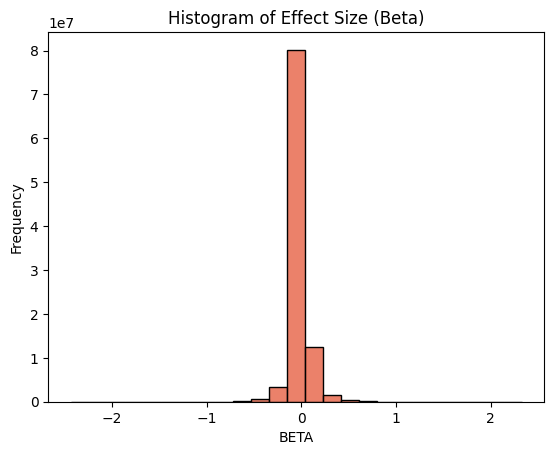

[INFO] Plotting 'EAF' (Effect Allele Frequency).


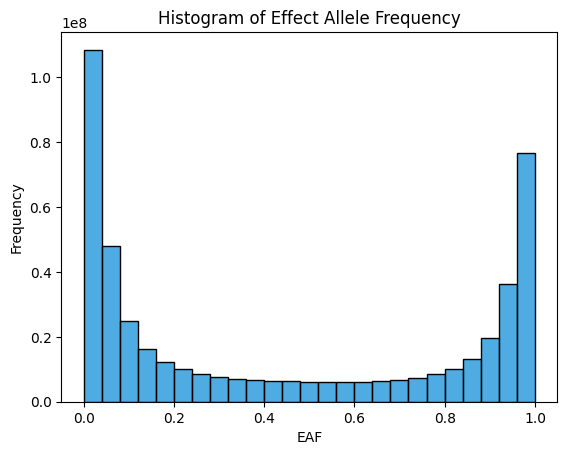

[INFO] Plotting 'SE' (Standard Error (SE)).


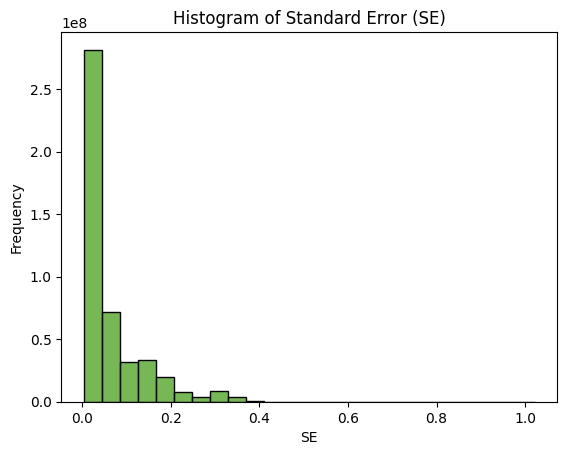

[INFO] Column 'INFO' (Imputation INFO Score) not present — skipping histogram.
[INFO] Plotting 'N' (Sample Size (N)).


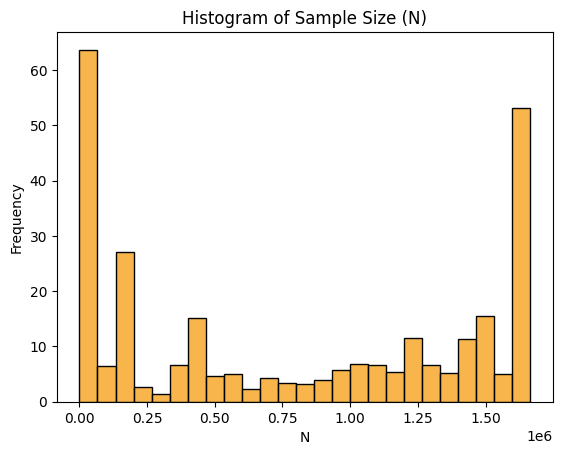

[INFO] Plotting 'N_cases' (Number of Cases).


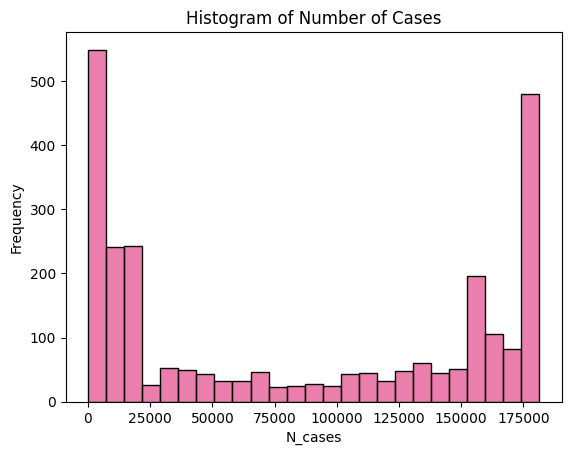

[INFO] Plotting 'N_controls' (Number of Controls).


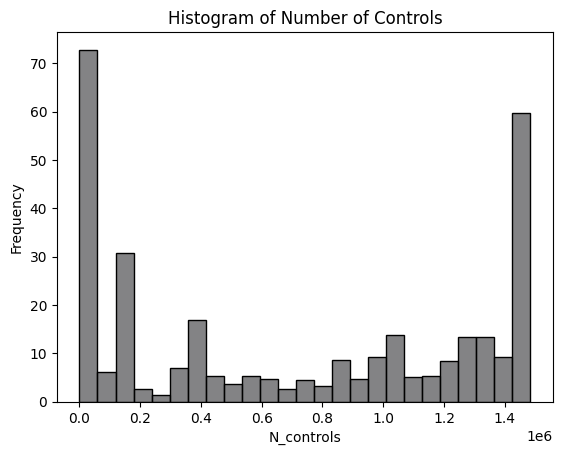

In [16]:
if not ONLY_QC and MAKE_FIGURES:
    print("\n[INFO] ===== Figures =====")

    # Column names are already standardised by block 4 — no alias resolution needed
    FIGURE_COLUMNS = {
        "BETA":       ("Effect Size (Beta)",      "#E55738"),
        "EAF":        ("Effect Allele Frequency", "#1290D9"),
        "SE":         ("Standard Error (SE)",     "#49A01D"),
        "INFO":       ("Imputation INFO Score",   "#705296"),
        "N":          ("Sample Size (N)",         "#F59D10"),
        "N_cases":    ("Number of Cases",         "#E35493"),
        "N_controls": ("Number of Controls",      "#595A5C"),
    }

    for col, (label, color) in FIGURE_COLUMNS.items():
        if col in gwas_data.columns:
            print(f"[INFO] Plotting '{col}' ({label}).")
            plot_histogram(
                gwas_data, col, label, color,
                os.path.join(PLOTS_loc, f"histogram.{col}.{PHENOTYPE}.raw.png"),
            )
        else:
            print(f"[INFO] Column '{col}' ({label}) not present — skipping histogram.")

## 11 · `basic_check`

We execute a basic check of the column corrected and standardized 'raw' GWAS dataset.


In [17]:
if not ONLY_QC:
    gwas_obj.basic_check(verbose=True)

2026/03/11 23:03:29 Start to check SNPID/rsID ...(v4.1.2)
2026/03/11 23:03:29  -Current Dataframe shape : 18842305 x 17 ; Memory usage: 2342.11 MB
2026/03/11 23:03:29  -Checking rsID data type...
2026/03/11 23:03:29  -Converted datatype for rsID: object -> string
2026/03/11 23:03:30  -Checking SNPID data type...
2026/03/11 23:03:30  -Converted datatype for SNPID: object -> string
2026/03/11 23:03:32  -Checking if SNPID contains NA strings :na,NA,Na,Nan,NaN,<NA>,null,NULL,#N/A,#VALUE!,N/A,n/a,missing,...
2026/03/11 23:03:33  -Checking if rsID contains NA strings :na,NA,Na,Nan,NaN,<NA>,null,NULL,#N/A,#VALUE!,N/A,n/a,missing,...
2026/03/11 23:03:35  -Checking if SNPID is CHR:POS:NEA:EA...(separator: - ,: , _)
2026/03/11 23:03:53  -Checking if rsID is rsxxxxxx...
2026/03/11 23:04:05  -Checking if CHR:POS:NEA:EA is mixed in rsID column ...
2026/03/11 23:04:16  -Number of CHR:POS:NEA:EA mixed in rsID column : 0
2026/03/11 23:04:16  -Number of Unrecognized rsID : 1960767
2026/03/11 23:04:17  

/Users/slaan3/miniforge3/envs/gwas2cojo/lib/python3.12/site-packages/gwaslab/qc/qc_sanity_check.py:509: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[True False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  is_close[valid_mask] = fold_change[valid_mask] <= fold_threshold


2026/03/11 23:07:23   -Potentially inconsistent (likely due to rounding): 12065294 variant(s)
2026/03/11 23:07:23   -Variant SNPID with max fold change: 1:216739919:G:A with 1.14x
2026/03/11 23:07:23   -Note: Minor differences are typically due to rounding.
2026/03/11 23:07:23    -If the max difference is greater than expected, please check your original sumstats.
2026/03/11 23:07:23  -Time taken: 79.196s
2026/03/11 23:07:23 Finished checking data consistency across columns.
2026/03/11 23:07:23 Start to normalize indels ...(v4.1.2)
2026/03/11 23:07:23  -Number of threads/cores to use: 1
2026/03/11 23:07:24  -Number of variants to check:31484
2026/03/11 23:07:24  -Chunk size:3000000
2026/03/11 23:07:24  -Processing in chunks:0 
2026/03/11 23:07:34  -Time taken: 10.938s
2026/03/11 23:07:34 Finished normalizing indels.
2026/03/11 23:07:34 Start to sort the genome coordinates ...(v4.1.2)
2026/03/11 23:07:58  -Time taken: 23.949s
2026/03/11 23:07:58 Finished sorting coordinates.
2026/03/11 

## 12 · `remove_dup`

We remove any duplicate bi- and multi-allelic variants, making sure that the most significant association for a given duplicate variant is retained.


In [18]:
if not ONLY_QC:
    gwas_obj.remove_dup(
        mode="md",      # remove multi-allelic AND duplicate variants
        keep_col="P",
        keep="first",   # after sorting by P ascending, keep first (lowest P)
    )

2026/03/11 23:08:06 Start to remove duplicated/multiallelic variants ...(v4.1.2)
2026/03/11 23:08:06  -Removing mode:md
2026/03/11 23:08:06 Start to sort the sumstats using P ...
2026/03/11 23:08:18 Start to remove duplicated variants based on snpid ...(v4.1.2)
2026/03/11 23:08:18  -Which variant to keep:  first
2026/03/11 23:08:55  -Removed variants based on SNPID: 0
2026/03/11 23:08:55 Start to remove duplicated variants based on rsID ...
2026/03/11 23:09:25  -Removed variants based on rsID: 44654
2026/03/11 23:09:25 Start to remove duplicated variants based on CHR,POS,EA and NEA ...
2026/03/11 23:09:25  -Current Dataframe shape : 18797651 x 17 ; Memory usage: 2448.15 MB
2026/03/11 23:09:25  -Which variant to keep:  first
2026/03/11 23:09:52  -Removed variants based on CHR,POS,EA and NEA: 4962
2026/03/11 23:09:52 Start to remove multiallelic variants based on chr:pos ...
2026/03/11 23:09:52  -Current Dataframe shape : 18792689 x 17 ; Memory usage: 2447.51 MB
2026/03/11 23:09:52  -Whi

In [19]:
print(f"[INFO] After duplicate removal: {len(gwas_obj.data):,} variants remain.")

[INFO] After duplicate removal: 18,745,694 variants remain.


## 13 · `check_ref` + `flip_allele_stats`


In [20]:
if not ONLY_QC:
    gwas_obj.check_ref(
        ref_seq=os.path.join(REF_loc, f"{REFERENCE}.fa.gz"),
    )
    gwas_obj.flip_allele_stats()

2026/03/11 23:20:10 Start to check if NEA is aligned with reference sequence ...(v4.1.2)
2026/03/11 23:20:10  -Current Dataframe shape : 18745694 x 17 ; Memory usage: 2298.39 MB
2026/03/11 23:20:11  -Reference genome FASTA file: /Users/slaan3/Library/CloudStorage/OneDrive-UMCUtrecht/Genomics/PLINK/references/gwaslab/hg38.fa.gz
2026/03/11 23:20:30    -Loading and building numpy fasta records:chr1  chr10  chr11  chr12  chr13  chr14  chr15  chr16  chr17  chr18  chr19  chr2  chr20  chr21  chr22  chr3  chr4  chr5  chr6  chr7  chr8  chr9  
2026/03/11 23:21:06  -Checking records
2026/03/11 23:21:12    -Checking records for ( len(NEA) <= 4 and len(EA) <= 4 )
2026/03/11 23:21:54    -Checking records for ( len(NEA) > 4 or len(EA) > 4 )
2026/03/11 23:22:14  -Finished checking records
2026/03/11 23:22:14  -Variants allele on given reference sequence :  9497898
2026/03/11 23:22:14  -Variants flipped :  7574491
2026/03/11 23:22:14   -Raw Matching rate :  91.07%
2026/03/11 23:22:14  -Variants inferre

: 

## 14 · `fix_id`


In [ ]:
if not ONLY_QC:
    gwas_obj.fix_id(fixid=True, forcefixid=True, overwrite=True)

## 15 · `infer_strand` + `flip_allele_stats`


In [ ]:
gwas_obj.data.head()

In [ ]:
if not ONLY_QC:
    print(f"Reference VCF: {vcf}")
    gwas_obj.infer_strand(ref_infer=vcf, ref_alt_freq="AF", threads=N_CORES)
    gwas_obj.flip_allele_stats()

## 16 · `assign_rsid` — dbSNP mapping (optional)

Only runs when `DO_DBSNP = True`.


In [ ]:
if not ONLY_QC and DO_DBSNP:
    dbsnp = dbsnp_vcf_path(REF_loc, REFERENCE)
    print(f"dbSNP VCF: {dbsnp}")
    gwas_obj.assign_rsid(
        threads=N_CORES,
        ref_rsid_vcf=dbsnp,
        chr_dict=gl.get_number_to_NC(build=REFERENCE),
    )
else:
    print("dbSNP rsID assignment skipped (DO_DBSNP=False).")

## 17 · `check_af`


In [ ]:
if not ONLY_QC:
    gwas_obj.check_af(ref_infer=vcf, ref_alt_freq="AF", threads=N_CORES)

## 18 · Save raw processed output (pickle + parquet + TSV.GZ)


In [ ]:
if not ONLY_QC:
    # Pickle
    print(f"[SAVE] Pickle → {pkl_path}")
    gl.dump_pickle(gwas_obj, pkl_path, overwrite=True)
    gwas_obj.log.show()
    gwas_obj.log.save(pkl_path.replace(".pkl", ".log"))

    # Parquet
    raw_parquet = os.path.join(OUTPUT_loc, f"{PHENOTYPE}.hg{REFERENCE}.gwaslab.parquet")
    print(f"[SAVE] Parquet → {raw_parquet}")
    pq.write_table(pa.Table.from_pandas(gwas_obj.data), raw_parquet, compression="BROTLI")

    # TSV.GZ
    raw_tsv = os.path.join(OUTPUT_loc, f"{PHENOTYPE}.hg{REFERENCE}.gwaslab.tsv")
    print(f"[SAVE] TSV.GZ → {raw_tsv}.gz")
    save_tsv_gz(reformat_output(pd.read_parquet(raw_parquet)), raw_tsv)

## 17 · Plots — full (pre-QC) dataset


In [ ]:
if not ONLY_QC and MAKE_FIGURES:
    daf_thr = DAF_MAX if DAF_MAX is not None else 0.12

    gwas_obj.plot_daf(
        threshold=daf_thr,
        save=os.path.join(PLOTS_loc, f"EAF.{PHENOTYPE}.png"),
    )

    gwas_obj.plot_mqq(
        skip=2, cut=10, mode="m",
        sig_line=True, sig_level=5e-8,
        anno="GENENAME", anno_style="right",
        windowsizekb=500, arm_offset=2, repel_force=0.02,
        use_rank=True, build=REFERENCE,
        stratified=True, drop_chr_start=True,
        title=PHENOTYPE,
        save=os.path.join(PLOTS_loc, f"manhattan.500kb.300dpi.{PHENOTYPE}.png"),
        saveargs={"dpi": 300}, verbose=True,
    )

    gwas_obj.plot_mqq(
        skip=2, cut=10, mode="qq",
        sig_line=True, sig_level=5e-8,
        arm_offset=2, repel_force=0.02,
        use_rank=True, build=REFERENCE,
        stratified=True, drop_chr_start=True,
        title=PHENOTYPE,
        save=os.path.join(PLOTS_loc, f"qq.500kb.300dpi.{PHENOTYPE}.png"),
        saveargs={"dpi": 300}, verbose=True,
    )

## 20 · QC filtering

Runs when `DO_QC = True` **or** `ONLY_QC = True`.


In [ ]:
if DO_QC or ONLY_QC:
    # Coerce numeric columns first
    coerce_numeric_cols(
        gwas_obj.data,
        ["EAF", "DAF", "BETA", "SE", "INFO", "MAC", "HWE_P",
         "N", "N_cases", "N_controls", "POS"],
    )
    # Fill DAF NaN with 0 so variants without a reference AF pass the filter
    if "DAF" in gwas_obj.data.columns and DAF_MAX is not None:
        gwas_obj.data["DAF"] = gwas_obj.data["DAF"].fillna(0.0)

    expr = build_qc_filter_expr(EAF_THRESHOLD, BETA_MAX, SE_MAX, INFO_MIN, DAF_MAX)
    print(f"QC filter expression: {expr}")

    gwas_obj_qc = gwas_obj.filter_value(expr=expr)
    print(f"Variants after QC: {len(gwas_obj_qc.data):,}")
    gwas_obj_qc.data.head()

## 21 · Save QC-filtered output


In [ ]:
if DO_QC or ONLY_QC:
    qc_pkl = os.path.join(OUTPUT_loc, f"{PHENOTYPE}.hg{REFERENCE}.gwaslab.qc.pkl")
    print(f"[SAVE] QC Pickle → {qc_pkl}")
    gl.dump_pickle(gwas_obj_qc, qc_pkl, overwrite=True)
    gwas_obj_qc.log.save(qc_pkl.replace(".pkl", ".log"))

    qc_parquet = os.path.join(OUTPUT_loc, f"{PHENOTYPE}.hg{REFERENCE}.gwaslab.qc.parquet")
    print(f"[SAVE] QC Parquet → {qc_parquet}")
    pq.write_table(pa.Table.from_pandas(gwas_obj_qc.data), qc_parquet, compression="BROTLI")

    qc_tsv = os.path.join(OUTPUT_loc, f"{PHENOTYPE}.hg{REFERENCE}.gwaslab.qc.tsv")
    print(f"[SAVE] QC TSV.GZ → {qc_tsv}.gz")
    save_tsv_gz(reformat_output(pd.read_parquet(qc_parquet)), qc_tsv)

## 22 · Plots — QC-filtered dataset


In [ ]:
if (DO_QC or ONLY_QC) and MAKE_FIGURES:
    daf_thr = DAF_MAX if DAF_MAX is not None else 0.12

    gwas_obj_qc.plot_daf(
        threshold=daf_thr,
        save=os.path.join(PLOTS_loc, f"EAF.{PHENOTYPE}.qc.png"),
    )

    gwas_obj_qc.plot_mqq(
        skip=2, cut=10, mode="m",
        sig_line=True, sig_level=5e-8,
        anno="GENENAME", anno_style="right",
        windowsizekb=500, arm_offset=2, repel_force=0.02,
        use_rank=True, build=REFERENCE,
        stratified=True, drop_chr_start=True,
        title=f"{PHENOTYPE} (QC)",
        save=os.path.join(PLOTS_loc, f"manhattan.500kb.300dpi.{PHENOTYPE}.qc.png"),
        saveargs={"dpi": 300}, verbose=True,
    )

    gwas_obj_qc.plot_mqq(
        skip=2, cut=10, mode="qq",
        sig_line=True, sig_level=5e-8,
        arm_offset=2, repel_force=0.02,
        use_rank=True, build=REFERENCE,
        stratified=True, drop_chr_start=True,
        title=f"{PHENOTYPE} (QC)",
        save=os.path.join(PLOTS_loc, f"qq.500kb.300dpi.{PHENOTYPE}.qc.png"),
        saveargs={"dpi": 300}, verbose=True,
    )

## 23 · Lead SNPs


In [ ]:
if SELECT_LEADS:
    source_obj  = gwas_obj_qc if (DO_QC or ONLY_QC) else gwas_obj
    suffix      = "qc.leads" if (DO_QC or ONLY_QC) else "leads"
    leads_tsv   = os.path.join(OUTPUT_loc, f"{PHENOTYPE}.hg{REFERENCE}.gwaslab.{suffix}.tsv")

    leads = source_obj.get_lead(anno=True, build=REFERENCE, sig_level=5e-8, verbose=True)

    if hasattr(leads, "to_csv"):
        leads.to_csv(leads_tsv, index=False)
        display(leads.head())
    elif hasattr(leads, "data"):
        leads.data.to_csv(leads_tsv, index=False)
        display(leads.data.head())

    print(f"[SAVE] Lead SNPs → {leads_tsv}")

## 22 · Done


In [ ]:
print("Pipeline complete.")
print(f"  Output directory : {OUTPUT_loc}")
print(f"  Plots directory  : {PLOTS_loc}")